# Weather Effects on Urban Air Pollution: Los Angeles vs Houston

**DSCI 510 — Final Project** : Xingtong Liu

## Introduction

This project examines how daily weather conditions relate to PM2.5 air pollution in Los Angeles and Houston during the first half of 2024. The study focuses on four weather variables: temperature, humidity, wind speed, and precipitation. It compares whether these factors are associated with PM2.5 in similar or different ways across the two cities. In addition, the project compares a Linear Regression baseline with a Random Forest model to determine whether a nonlinear model can better predict PM2.5.

## Data sources

| # | Source | Type | Used for |
|---|---|---|---|
| 1 | EPA Air Quality System (AQS) API | API (JSON) | Daily PM2.5 and AQI by county |
| 2 | Open-Meteo Historical Weather API | API (JSON) | Daily temperature, humidity, wind speed, and precipitation |
| 3 | EPA AirData historical CSV | File (CSV) | Independent daily AQI used to cross-validate the EPA API values |

## Notebook structure

1. Dataset overview  
2. Exploratory data analysis  
3. Correlation analysis  
4. Cross-source validation  
5. Modeling  
6. Conclusions

## 0. Setup

In [1]:
# Add src/ to the path and switch to the src directory so the project
# modules and relative paths work correctly.
import os, sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT / "src")

import pandas as pd
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

from config import FEATURE_COLS, TARGET_COL
from process import (
    build_epa_daily_pm25, build_weather_daily,
    merge_air_weather, build_epa_airdata_daily,
)
from analyze import (
    describe_dataset,
    plot_timeseries,
    plot_distribution_by_city,
    plot_boxplot_by_city,
    plot_weather_vs_pm25,
    plot_correlation_heatmap,
    correlation_table_by_city,
    compare_epa_sources,
)
from models import compare_cities, plot_feature_importance

email = os.getenv("EPA_EMAIL")
key = os.getenv("EPA_KEY")

epa_daily = build_epa_daily_pm25(email, key)
weather_daily = build_weather_daily()
merged = merge_air_weather(epa_daily, weather_daily)
airdata = build_epa_airdata_daily()

print(f"Merged dataset: {len(merged)} rows × {merged.shape[1]} columns")
merged.head()


  20240101 to 20240131
  20240201 to 20240229
  20240301 to 20240331
  20240401 to 20240430
  20240501 to 20240531
  20240601 to 20240630
  20240101 to 20240131
  20240201 to 20240229
  20240301 to 20240331
  20240401 to 20240430
  20240501 to 20240531
  20240601 to 20240630
Loaded EPA AirData CSV: 329166 rows
Merged dataset: 364 rows × 8 columns


,city,date,pm25,aqi,temperature,humidity,wind_speed,precipitation
0,Houston,2024-01-01,54.642603,125.100000,14.7,82,11.4,2.5
1,Houston,2024-01-02,8.584038,46.555556,9.5,70,15.2,7.7
2,Houston,2024-01-03,8.743524,47.500000,10.0,82,15.2,29.7
3,Houston,2024-01-04,9.252080,47.909091,9.8,74,15.2,0.0
4,Houston,2024-01-05,5.647940,31.000000,12.5,80,17.9,55.6


## 1. Dataset overview

In [3]:
describe_dataset(merged)

--- Dataset shape ---
(364, 8)

--- Missing values ---
city             0
date             0
pm25             0
aqi              0
temperature      0
humidity         0
wind_speed       0
precipitation    0
dtype: int64

--- Summary statistics by city ---
city                             Houston          Los Angeles
date          count                  182                  182
              mean   2024-03-31 12:00:00  2024-03-31 12:00:00
              min    2024-01-01 00:00:00  2024-01-01 00:00:00
              25%    2024-02-15 06:00:00  2024-02-15 06:00:00
              50%    2024-03-31 12:00:00  2024-03-31 12:00:00
              75%    2024-05-15 18:00:00  2024-05-15 18:00:00
              max    2024-06-30 00:00:00  2024-06-30 00:00:00
              std                    NaN                  NaN
pm25          count                182.0                182.0
              mean             10.848401             8.961784
              min               2.982965             1.723913


## 2. Exploratory data analysis

### 2.1 Time series

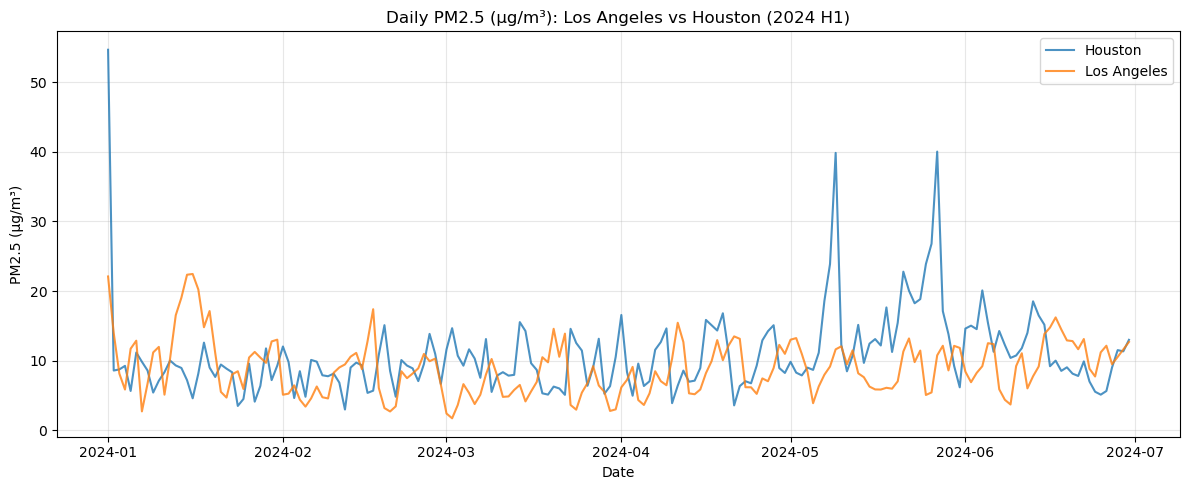

In [4]:
plot_timeseries(merged, "pm25", "PM2.5 (µg/m³)", notebook_plot=True)

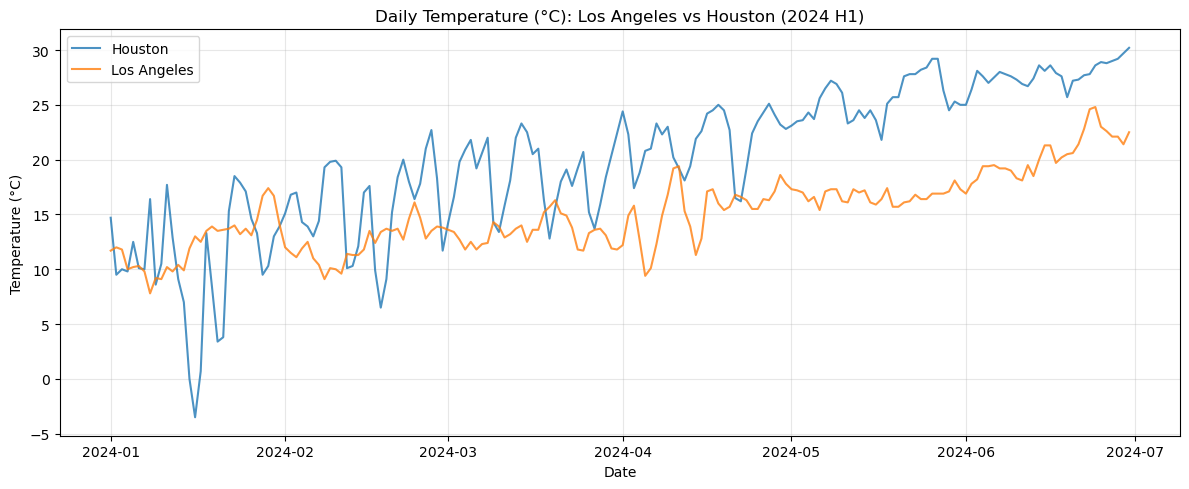

In [5]:
plot_timeseries(merged, "temperature", "Temperature (°C)", notebook_plot=True)

### 2.2 Distribution of PM2.5 by city

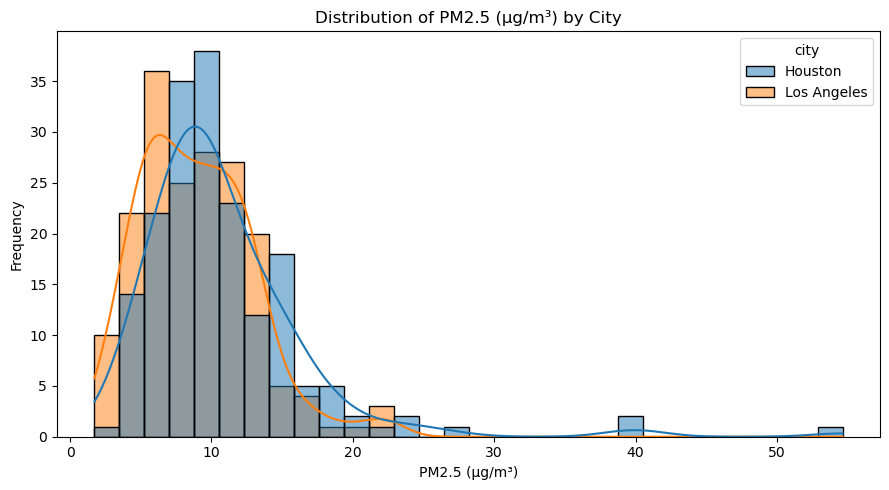

In [6]:
plot_distribution_by_city(merged, "pm25", "PM2.5 (µg/m³)", notebook_plot=True)

### 2.3 Side-by-side boxplots

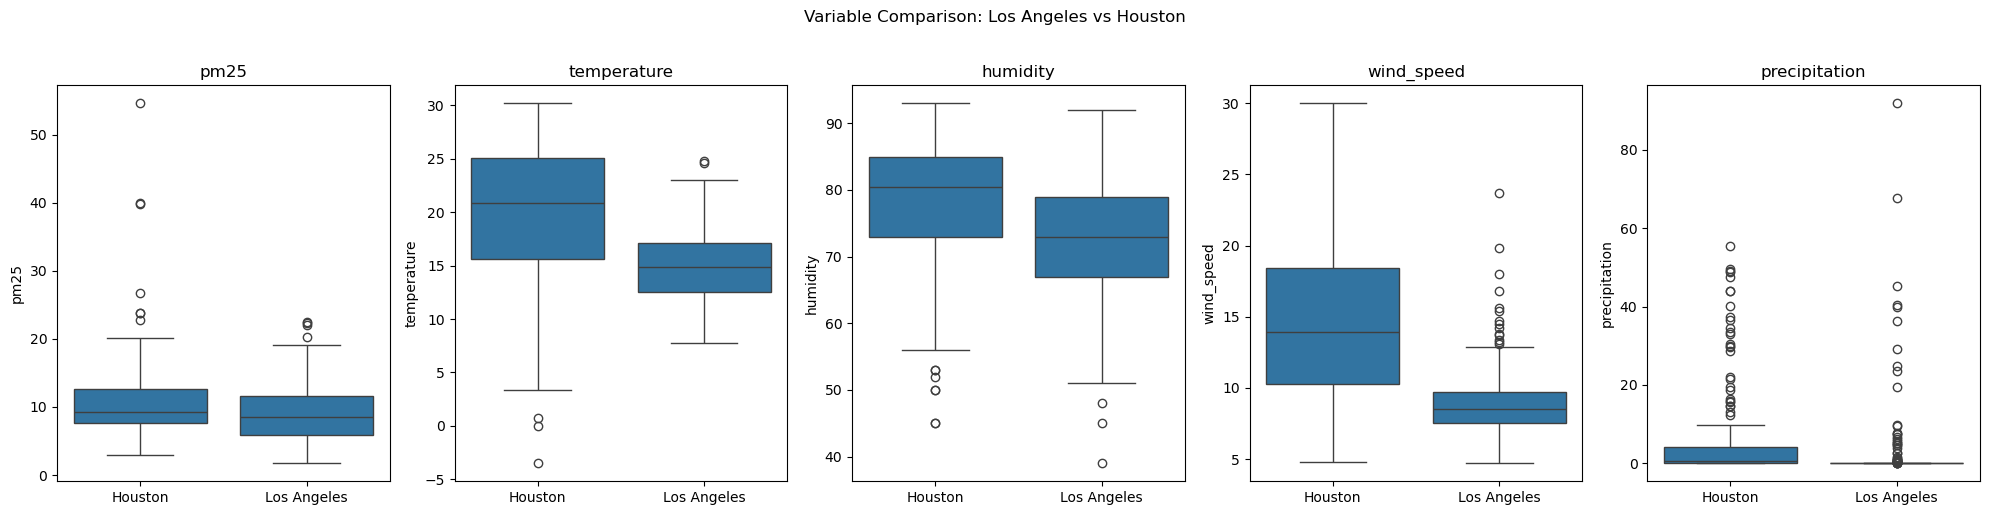

In [7]:
plot_boxplot_by_city(
    merged,
    ["pm25", "temperature", "humidity", "wind_speed", "precipitation"],
    notebook_plot=True,
)


### 2.4 PM2.5 vs weather scatter

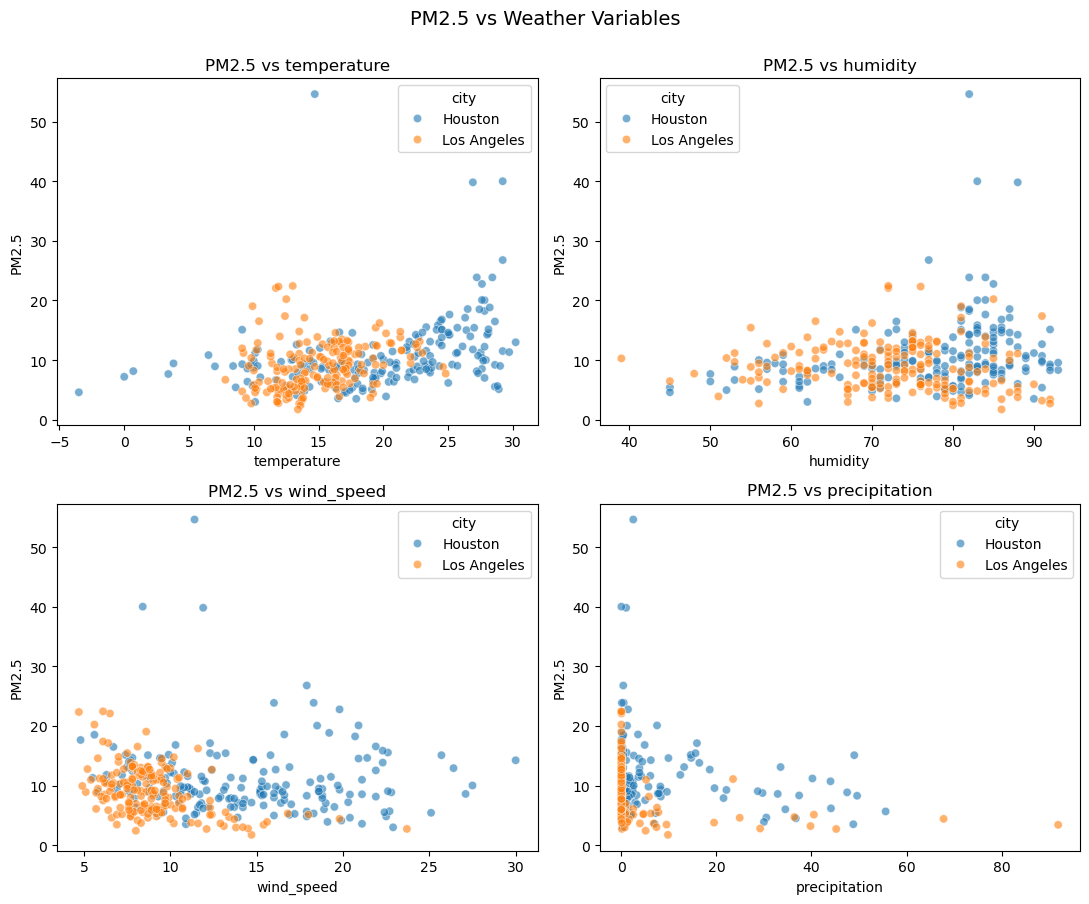

In [8]:
plot_weather_vs_pm25(merged, FEATURE_COLS, notebook_plot=True)

## 3. Correlation analysis

Pearson correlation between PM2.5 and each weather variable, computed separately for each city.


### 3.1 Correlation heatmaps per city

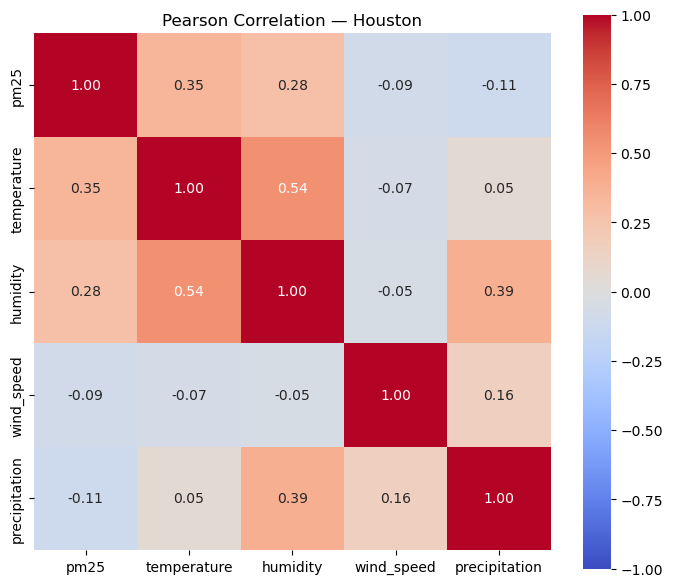

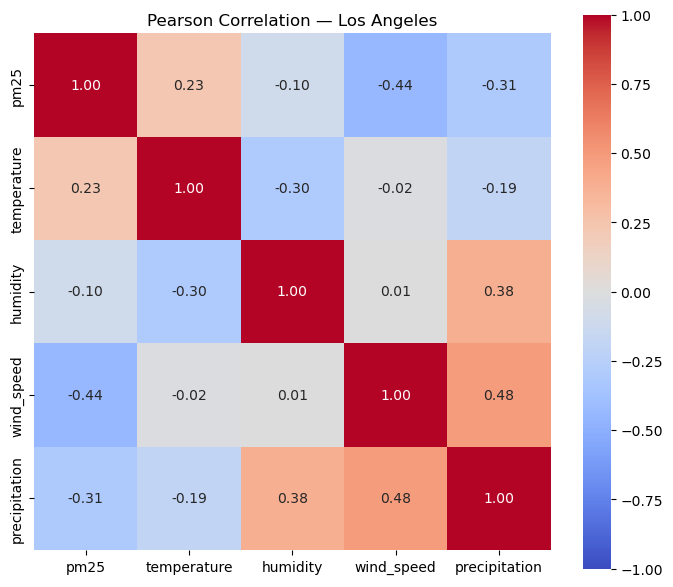

In [9]:
corr_cols = [TARGET_COL] + FEATURE_COLS
for city in merged["city"].unique():
    plot_correlation_heatmap(merged, corr_cols, city, notebook_plot=True)


### 3.2 Correlation with PM2.5, side by side

In [10]:
correlation_table_by_city(merged, FEATURE_COLS, target_col=TARGET_COL)

,Houston,Los Angeles
temperature,0.347,0.230
humidity,0.277,-0.101
wind_speed,-0.088,-0.441
precipitation,-0.113,-0.306


## 4. Cross-source validation

The EPA AirData CSV provides an independently aggregated daily AQI. Merging it with the EPA API values and checking the Pearson correlation confirms that the two sources agree.


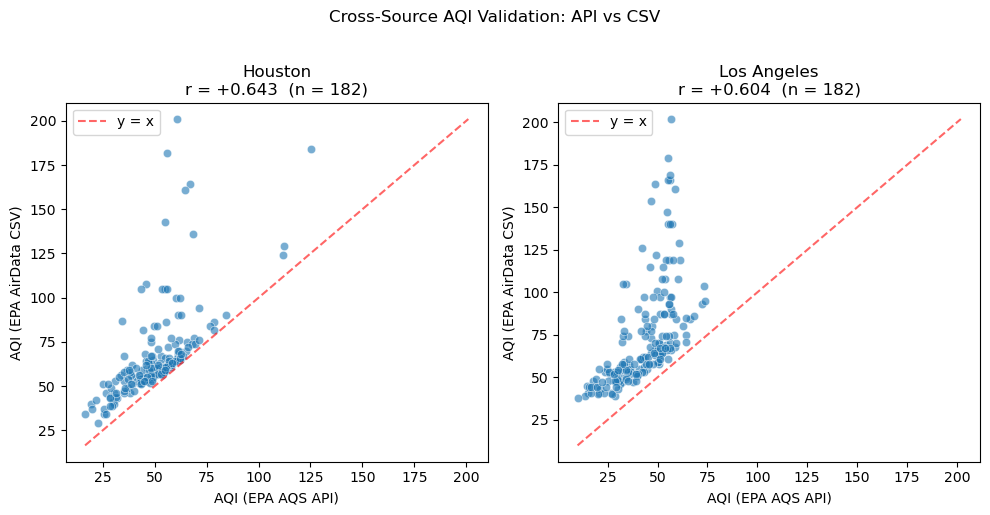

,city,n_days,pearson_r
0,Houston,182,0.643
1,Los Angeles,182,0.604


In [11]:
epa_slim = merged[["city", "date", "aqi"]]
_, cross_source_summary = compare_epa_sources(epa_slim, airdata, notebook_plot=True)
cross_source_summary


## 5. Modeling

For each city, we fit two models on the same 80/20 train/test split so that their test R² and RMSE are directly comparable:

- **Linear Regression** — simple baseline, assumes PM2.5 is a linear function of the weather variables.
- **Random Forest** — captures nonlinear effects and variable interactions, and gives us a feature-importance ranking.


### 5.1 Model comparison

In [12]:
comparison, importance, per_city = compare_cities(merged)
comparison


Saved model_comparison.csv and rf_feature_importance.csv


,city,n,lr_test_r2,rf_test_r2,lr_test_rmse,rf_test_rmse
0,Houston,182,0.259,0.222,4.208,4.313
1,Los Angeles,182,0.146,0.249,4.169,3.911


### 5.2 Random Forest feature importance

In [13]:
importance

,Houston importance,Los Angeles importance
feature,,
temperature,0.4357,0.2943
wind_speed,0.2285,0.2810
humidity,0.2229,0.1369
precipitation,0.1129,0.2878


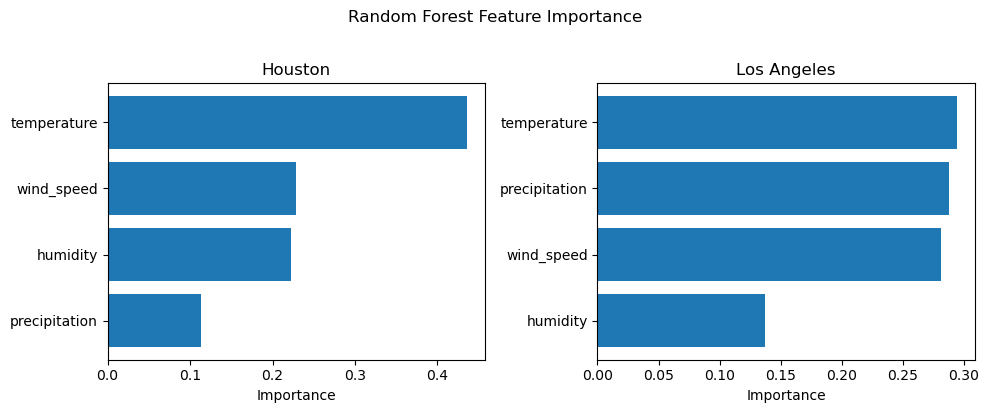

In [14]:
plot_feature_importance(per_city, notebook_plot=True)

## 6. Conclusions

This notebook shows that weather variables are associated with PM2.5 in both Los Angeles and Houston, but the relationships are not exactly the same across the two cities. The correlation analysis suggests that local weather conditions may influence air pollution differently in each location. The modeling results also provide a comparison between a simple Linear Regression baseline and a Random Forest model, helping evaluate whether nonlinear relationships improve prediction performance.